In [25]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential, Model
from keras.layers import Dense, Input, Flatten, Conv2D, MaxPool2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.datasets.fashion_mnist import load_data
from keras.utils import to_categorical
from keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions 
from keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'

In [26]:
dataGen = ImageDataGenerator(rescale=1./255)
imgGen = dataGen.flow_from_directory('../../shapes', target_size=(100,100))
imgGen

Found 14970 images belonging to 4 classes.


In [27]:
x_data, y_data = next(imgGen)

In [28]:
x_data.shape

(32, 100, 100, 3)

In [29]:
y_data.shape

(32, 4)

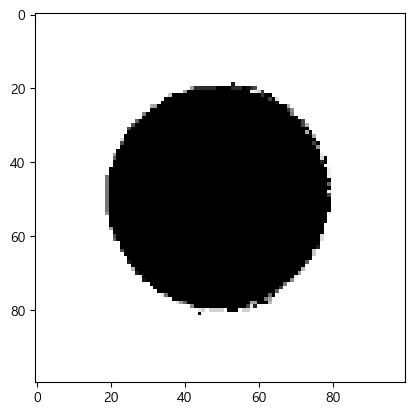

In [30]:
plt.imshow(x_data[0])
plt.show()

In [31]:
y_data[0]

array([1., 0., 0., 0.], dtype=float32)

In [32]:
imgGen.class_indices

{'circle': 0, 'square': 1, 'star': 2, 'triangle': 3}

---

딥러닝 학습

In [ ]:
model = Sequential()
# 특징추출기 
model.add(Conv2D(64, kernel_size=(3,3), strides=1, input_shape=(100,100,3),activation='relu', padding='same')) 
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
# 분류기
model.add(Flatten())
model.add(Dense(units=64, activation='relu')) 
model.add(Dense(units=4, activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])
# model.summary() 파라미터수 확인
model.fit(imgGen, epochs=10)
# model.fit(imgGen, epochs=10, steps_per_epoch=100) 전체 데이터 중 100개만 추출해서 반복

Epoch 1/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - acc: 0.9801 - loss: 0.1515
Epoch 2/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - acc: 1.0000 - loss: 3.8535e-05
Epoch 3/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 60s 129ms/step - acc: 1.0000 - loss: 1.0279e-05
Epoch 4/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - acc: 1.0000 - loss: 5.7704e-06
Epoch 5/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 60s 129ms/step - acc: 1.0000 - loss: 3.3029e-06
Epoch 6/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 61s 130ms/step - acc: 1.0000 - loss: 1.9272e-06
Epoch 7/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 88s 189ms/step - acc: 1.0000 - loss: 1.3308e-06
Epoch 8/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 81s 171ms/step - acc: 1.0000 - loss: 9.2836e-07
Epoch 9/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 60s 127ms/step - acc: 1.0000 - loss: 7.0119e-07
Epoch 10/10
468/468 ━━━━━━━━━━━━━━━━━━━━ 59s 126ms/step - acc: 1.0000 - loss: 5.4671e-07


---

### star

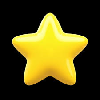

In [35]:
starimg = load_img('C:\deepTest\star.jpg', target_size=(100,100))
starimg

In [ ]:
imgArr = img_to_array(starimg)/255 #{'circle': 0, 'square': 1, 'star': 2, 'triangle': 3}
model.predict(imgArr.reshape(1,100,100,3)).argmax(axis=1) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


array([2])

In [ ]:
imgGen.class_indices

{'circle': 0, 'square': 1, 'star': 2, 'triangle': 3}

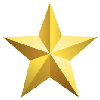

In [ ]:
star1img = load_img('C:\deepTest\star2.jpg', target_size=(100,100))
star1img

In [ ]:
imgArr = img_to_array(star1img)/255
model.predict(imgArr.reshape(1,100,100,3)).argmax(axis=1)
# {'circle': 0, 'square': 1, 'star': 2, 'triangle': 3}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


array([2])

---

### 사각형

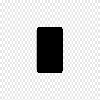

In [ ]:
squareimg = load_img('C:\deepTest\square.png',target_size=(100,100))
squareimg

In [ ]:
imgArr = img_to_array(squareimg)/255
model.predict(imgArr.reshape(1,100,100,3)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([3])

In [ ]:
imgGen.class_indices

{'circle': 0, 'square': 1, 'star': 2, 'triangle': 3}

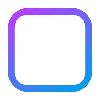

In [ ]:
squareimg1 = load_img('C:\deepTest\square1.png',target_size=(100,100))
squareimg1

In [ ]:
imgArr = img_to_array(squareimg1)/255
model.predict(imgArr.reshape(1,100,100,3)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


array([0])

---

### 삼각형

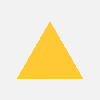

In [ ]:
triangleimg = load_img('C:/deepTest/triangle.png',target_size=(100,100))
triangleimg

In [ ]:
imgArr = img_to_array(triangleimg)/255
model.predict(imgArr.reshape(1,100,100,3)).argmax(axis=1)
# {'circle': 0, 'square': 1, 'star': 2, 'triangle': 3}

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


array([3])

---

### 원

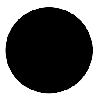

In [59]:
circleimg1 = load_img('C:\deepTest\circle1.png',target_size=(100,100))
circleimg1

In [60]:
imgArr2 = img_to_array(circleimg1)/255
model.predict(imgArr2.reshape(1,100,100,3)).argmax(axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


array([0])